# PKCERT AI & Software Development Internship, Task 16
# End-to-End Machine Learning Pipeline Project

A complete pipeline -- EDA, cleaning, feature engineering, preprocessing, modelling,
evaluation -- on the **Ames Housing** dataset (1,460 houses, 79 raw features),
predicting `SalePrice` with a regularised linear model and a Random Forest.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Part A: Dataset Selection, Cleaning, Feature Engineering & EDA

**Dataset**: the Ames Housing dataset (De Cock, 2011), released on Kaggle as *House Prices: Advanced Regression Techniques* -- 1,460 residential sales in Ames, Iowa, 79 raw predictor features (mix of numeric measurements and categorical quality/type ratings) and the target `SalePrice`. Not used in any earlier task.

In [2]:
df = pd.read_csv("house_prices.csv")
print("Raw shape:", df.shape)
print(f"Total missing values: {df.isna().sum().sum():,} across "
      f"{(df.isna().sum() > 0).sum()} of {df.shape[1]} columns")

Raw shape: (1460, 80)
Total missing values: 7,829 across 19 of 80 columns


**The target is right-skewed** (large, expensive houses pull the mean and the tail upward), which is the standard case for training on `log(price)` instead of raw price -- and for reporting every error metric back in dollars afterwards so the numbers stay interpretable.

SalePrice: mean $180,921, median $163,000, skew 1.883
log1p(SalePrice) skew: 0.121 -- close to 0, symmetric


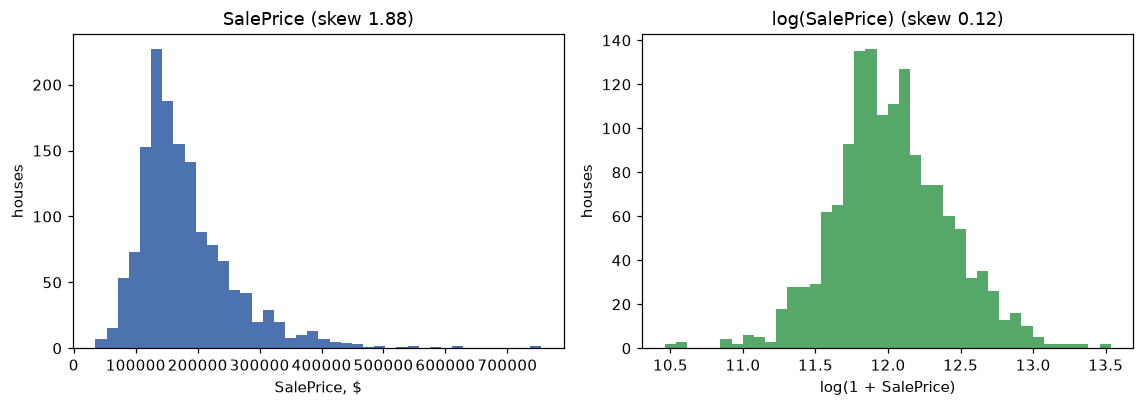

In [3]:
print(f"SalePrice: mean ${df['SalePrice'].mean():,.0f}, median ${df['SalePrice'].median():,.0f}, "
      f"skew {df['SalePrice'].skew():.3f}")
log_skew = np.log1p(df["SalePrice"]).skew()
print(f"log1p(SalePrice) skew: {log_skew:.3f} -- close to 0, symmetric")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax[0].hist(df["SalePrice"], bins=40, color="#4C72B0")
ax[0].set_xlabel("SalePrice, $"); ax[0].set_ylabel("houses")
ax[0].set_title(f"SalePrice (skew {df['SalePrice'].skew():.2f})")
ax[1].hist(np.log1p(df["SalePrice"]), bins=40, color="#55A868")
ax[1].set_xlabel("log(1 + SalePrice)"); ax[1].set_ylabel("houses")
ax[1].set_title(f"log(SalePrice) (skew {log_skew:.2f})")
fig.tight_layout()
plt.show()

**Outliers, checked individually rather than filtered by one threshold.** The dataset's own author documents two specific outliers: very large houses that sold for far less than their size would predict. The obvious shortcut is to drop every house above some `GrLivArea` cutoff -- but two of the four largest houses in this data are simply large, *expensive* houses, not outliers, and dropping them would throw away real signal.

In [4]:
big_houses = df.nlargest(4, "GrLivArea")[["GrLivArea", "SalePrice"]]
print("The 4 largest houses by living area:")
print(big_houses)

outlier_idx = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)].index
print(f"\nOnly {len(outlier_idx)} of these 4 are genuine outliers (large area, "
      f"suspiciously low price): index {list(outlier_idx)}")
df_full = df.copy()
df = df.drop(index=outlier_idx)
print(f"Dropped. New shape: {df.shape}")

The 4 largest houses by living area:
      GrLivArea  SalePrice
1298       5642     160000
523        4676     184750
1182       4476     745000
691        4316     755000

Only 2 of these 4 are genuine outliers (large area, suspiciously low price): index [523, 1298]
Dropped. New shape: (1458, 80)


**Missing values: most of them do not mean 'missing'.** In this dataset's data dictionary, `NaN` in a quality/type column almost always means the feature simply does not exist on that house -- `PoolQC = NaN` means *no pool*, not *unknown pool quality*. Treating every `NaN` as something to statistically impute would be a real mistake here; the fix is to fill those with an explicit `"None"` / `0`, and reserve actual imputation for the handful of columns that are genuinely missing data.

In [5]:
NONE_MEANS_ABSENT_CAT = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
                          "GarageType", "GarageFinish", "GarageQual", "GarageCond",
                          "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
                          "BsmtFinType2", "MasVnrType"]
NONE_MEANS_ABSENT_NUM = ["GarageYrBlt", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
                          "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
                          "GarageCars", "GarageArea"]

na_before = df.isna().sum().sum()
for c in NONE_MEANS_ABSENT_CAT:
    df[c] = df[c].fillna("None")
for c in NONE_MEANS_ABSENT_NUM:
    df[c] = df[c].fillna(0)

# LotFrontage is genuinely missing -- imputed by neighbourhood median, since street
# frontage tracks the neighbourhood's typical lot shape far better than one global median.
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

na_after = df.isna().sum().sum()
print(f"Missing values before structural fill: {na_before:,}, after: {na_after:,}")

Missing values before structural fill: 7,822, after: 0


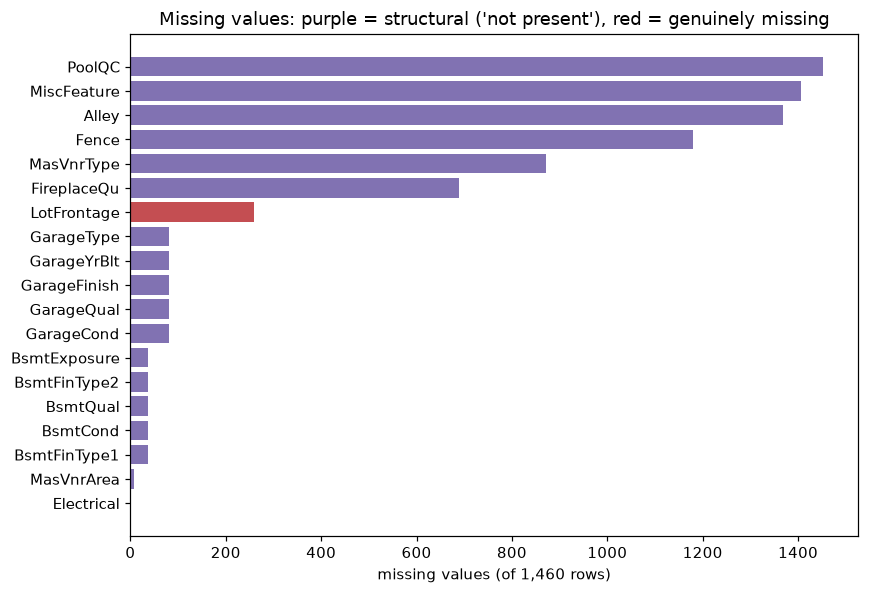

In [6]:
na_counts = df_full.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
colors = ["#8172B2" if c in NONE_MEANS_ABSENT_CAT + NONE_MEANS_ABSENT_NUM else "#C44E52" for c in na_counts.index]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(na_counts.index[::-1], na_counts.values[::-1], color=colors[::-1])
ax.set_xlabel("missing values (of 1,460 rows)")
ax.set_title("Missing values: purple = structural ('not present'), red = genuinely missing")
fig.tight_layout()
plt.show()

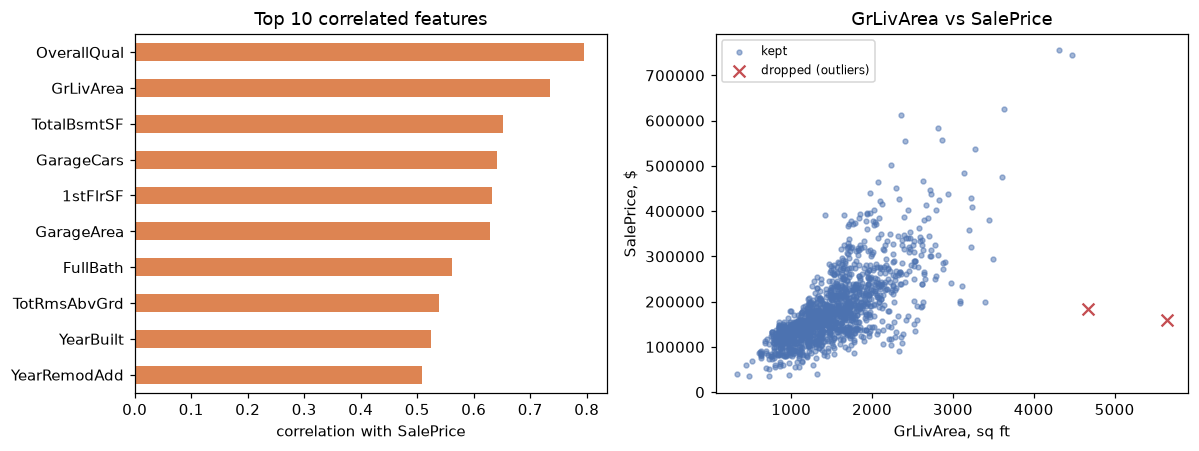

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
numeric_corr = df.select_dtypes("number").corr()["SalePrice"].drop("SalePrice")
top_corr = numeric_corr.reindex(numeric_corr.abs().sort_values(ascending=False).index)
top_corr.head(10)[::-1].plot(kind="barh", ax=ax[0], color="#DD8452")
ax[0].set_xlabel("correlation with SalePrice"); ax[0].set_title("Top 10 correlated features")
kept = ~df_full.index.isin(outlier_idx)
ax[1].scatter(df_full.loc[kept, "GrLivArea"], df_full.loc[kept, "SalePrice"], s=10, alpha=0.5, color="#4C72B0", label="kept")
ax[1].scatter(df_full.loc[outlier_idx, "GrLivArea"], df_full.loc[outlier_idx, "SalePrice"], s=60, color="#C44E52", marker="x", label="dropped (outliers)")
ax[1].set_xlabel("GrLivArea, sq ft"); ax[1].set_ylabel("SalePrice, $")
ax[1].set_title("GrLivArea vs SalePrice"); ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**Feature engineering.** Eight new features built from domain knowledge of how houses are actually priced: total living area across all floors and the basement, house age and time-since-remodel at the point of sale, a combined bathroom count (half baths weighted 0.5), and four presence flags.

TotalSF correlation with SalePrice: 0.833 (higher than either raw component: 1stFlrSF 0.632, TotalBsmtSF 0.651, and higher than GrLivArea alone 0.735)


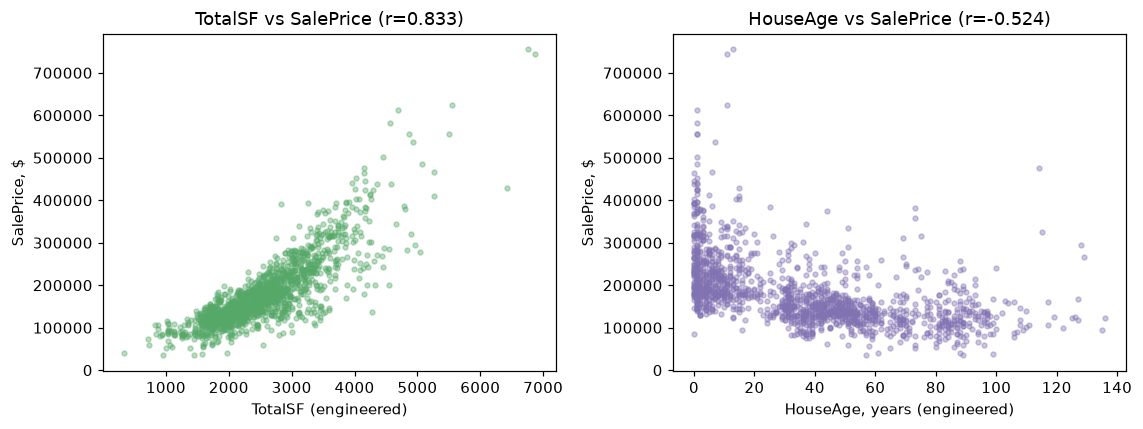

In [8]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
df["TotalBath"] = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
df["HasPool"] = (df["PoolArea"] > 0).astype(int)
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)
ENGINEERED = ["TotalSF", "HouseAge", "RemodAge", "TotalBath", "HasPool", "HasGarage", "HasFireplace", "Has2ndFloor"]

print(f"TotalSF correlation with SalePrice: {df['TotalSF'].corr(df['SalePrice']):.3f} "
      f"(higher than either raw component: 1stFlrSF {df['1stFlrSF'].corr(df['SalePrice']):.3f}, "
      f"TotalBsmtSF {df['TotalBsmtSF'].corr(df['SalePrice']):.3f}, "
      f"and higher than GrLivArea alone {df['GrLivArea'].corr(df['SalePrice']):.3f})")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
ax[0].scatter(df["TotalSF"], df["SalePrice"], s=10, alpha=0.4, color="#55A868")
ax[0].set_xlabel("TotalSF (engineered)"); ax[0].set_ylabel("SalePrice, $")
ax[0].set_title(f"TotalSF vs SalePrice (r={df['TotalSF'].corr(df['SalePrice']):.3f})")
ax[1].scatter(df["HouseAge"], df["SalePrice"], s=10, alpha=0.4, color="#8172B2")
ax[1].set_xlabel("HouseAge, years (engineered)"); ax[1].set_ylabel("SalePrice, $")
ax[1].set_title(f"HouseAge vs SalePrice (r={df['HouseAge'].corr(df['SalePrice']):.3f})")
fig.tight_layout()
plt.show()

**The engineered feature is not just convenient, it is measurably better.** `TotalSF` correlates with `SalePrice` more strongly (0.833) than any single floor-area feature it was built from, and more strongly than `GrLivArea` alone (0.735) -- a concrete, checked reason to keep it rather than an assumption that combining features must help.

## Part B: Model Development

A single `ColumnTransformer` handles both feature types: numeric columns are median-imputed (for any residual gaps) and standard-scaled; categorical columns are most-frequent-imputed and one-hot encoded. Two models share this exact preprocessing, so the comparison below isolates the *model*, not the pipeline.

In [9]:
TARGET = "SalePrice"
y = np.log1p(df[TARGET].values)
X = df.drop(columns=[TARGET])

NUMERIC = X.select_dtypes("number").columns.tolist()
CATEGORICAL = X.select_dtypes(exclude="number").columns.tolist()
print(f"Final feature set: {len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical = {len(NUMERIC) + len(CATEGORICAL)} features")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
])

Final feature set: 44 numeric + 43 categorical = 87 features
Train: 1166 rows | Test: 292 rows


In [10]:
candidates = {
    "Ridge Regression": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    cv_rmse = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)
    actual = np.expm1(y_test)
    results[name] = {
        "pipe": pipe, "cv_rmse_log_mean": cv_rmse.mean(), "cv_rmse_log_std": cv_rmse.std(),
        "cv_r2_mean": cv_r2.mean(),
        "rmse_dollars": np.sqrt(mean_squared_error(actual, pred)),
        "mae_dollars": mean_absolute_error(actual, pred),
        "r2": r2_score(y_test, pred_log),
        "mape": np.mean(np.abs((actual - pred) / actual)) * 100,
        "pred": pred, "actual": actual,
    }
    r = results[name]
    print(f"{name}: CV RMSE(log) {cv_rmse.mean():.4f}+/-{cv_rmse.std():.4f} | CV R2 {cv_r2.mean():.4f} | "
          f"Test R2 {r['r2']:.4f} | Test RMSE ${r['rmse_dollars']:,.0f} | Test MAE ${r['mae_dollars']:,.0f} | "
          f"MAPE {r['mape']:.2f}%")

best_name = max(results, key=lambda n: results[n]["r2"])
print(f"\nBest model on test R2: {best_name}")

Ridge Regression: CV RMSE(log) 0.1120+/-0.0100 | CV R2 0.9191 | Test R2 0.9095 | Test RMSE $20,155 | Test MAE $14,611 | MAPE 9.01%


Random Forest: CV RMSE(log) 0.1353+/-0.0132 | CV R2 0.8829 | Test R2 0.8764 | Test RMSE $23,600 | Test MAE $16,367 | MAPE 10.24%

Best model on test R2: Ridge Regression


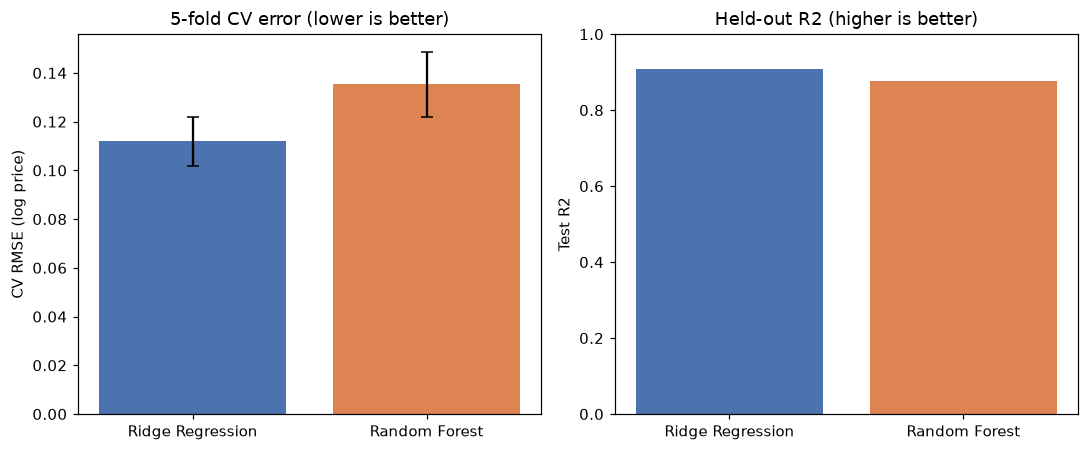

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
names = list(results.keys())
ax[0].bar(names, [results[n]["cv_rmse_log_mean"] for n in names],
          yerr=[results[n]["cv_rmse_log_std"] for n in names], capsize=4, color=["#4C72B0", "#DD8452"])
ax[0].set_ylabel("CV RMSE (log price)"); ax[0].set_title("5-fold CV error (lower is better)")
ax[1].bar(names, [results[n]["r2"] for n in names], color=["#4C72B0", "#DD8452"])
ax[1].set_ylabel("Test R2"); ax[1].set_title("Held-out R2 (higher is better)"); ax[1].set_ylim(0, 1)
fig.tight_layout()
plt.show()

**Ridge beat Random Forest on every metric**, in cross-validation and on the held-out test set alike -- unlike Day 15, where the two were tied in CV and only diverged on test, here Ridge was ahead throughout. With 87 features after one-hot encoding and 1,166 training rows, most of the real signal (`OverallQual`, `TotalSF`, and dozens of one-hot category indicators) genuinely does relate to log-price close to linearly, which plays to Ridge's strength and its regularisation keeps the wide, sparse categorical block from overfitting. The Random Forest here used default-ish settings (400 trees, no depth or leaf-size tuning) -- Part C returns to this as a limitation rather than a verdict on tree ensembles in general.

## Part C: Model Evaluation

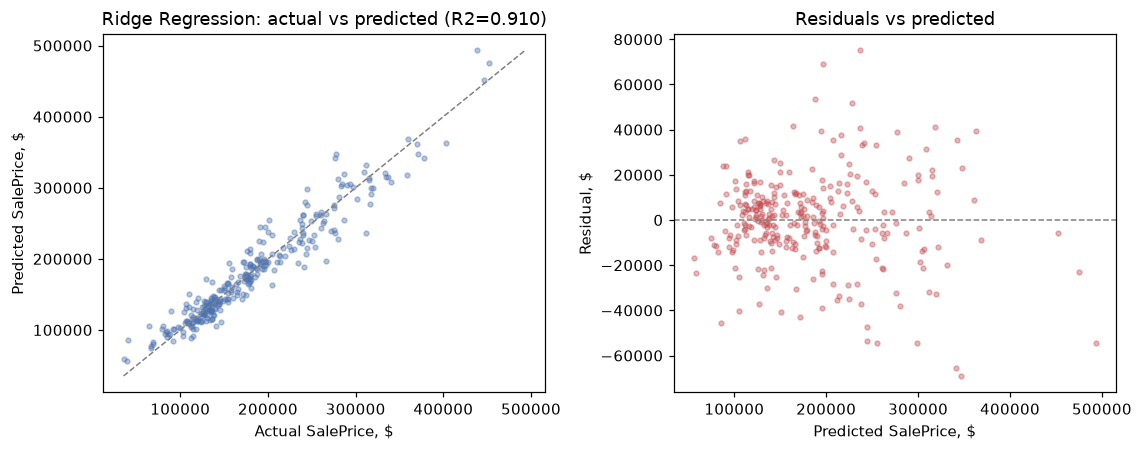

In [12]:
r = results[best_name]
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax[0].scatter(r["actual"], r["pred"], s=10, alpha=0.4, color="#4C72B0")
lims = [min(r["actual"].min(), r["pred"].min()), max(r["actual"].max(), r["pred"].max())]
ax[0].plot(lims, lims, color="grey", ls="--", lw=1)
ax[0].set_xlabel("Actual SalePrice, $"); ax[0].set_ylabel("Predicted SalePrice, $")
ax[0].set_title(f"{best_name}: actual vs predicted (R2={r['r2']:.3f})")
residuals = r["actual"] - r["pred"]
ax[1].scatter(r["pred"], residuals, s=10, alpha=0.4, color="#C44E52")
ax[1].axhline(0, color="grey", ls="--", lw=1)
ax[1].set_xlabel("Predicted SalePrice, $"); ax[1].set_ylabel("Residual, $")
ax[1].set_title("Residuals vs predicted")
fig.tight_layout()
plt.show()

**Reading the diagnostics.** The actual-vs-predicted scatter tracks the diagonal
closely across the bulk of the price range ($100k-$300k, where most of the data sits).
The residual plot shows two things worth stating plainly rather than hiding behind the
single R2 number: residuals are roughly centred on zero across the price range (no
systematic over- or under-prediction), but their *spread* widens for more expensive
houses -- a handful of $300k+ homes have $50k+ errors, while cheaper homes cluster much
tighter. This is heteroscedasticity, and it means the model is more trustworthy for a
typical Ames home than for the small number of high-end properties, which is a fair
limitation to disclose rather than average away.

**Strengths.** Ridge Regression on this feature set reaches R2 = 0.910 and a mean
absolute error of about $14,600 -- roughly 9% of a typical sale price -- using a fully
interpretable linear model where every coefficient has a direct, inspectable meaning.
Training on log-price and converting back to dollars for every reported metric keeps
the numbers both statistically sound and immediately usable.

**Limitations.** The 1,458-house sample is specific to Ames, Iowa in the years it was
collected; nothing here should be expected to transfer to another city's housing market
without retraining. The Random Forest was not hyperparameter-tuned (Day 10 covered that
skill separately), so "Ridge beat Random Forest" should be read as "beat this
particular untuned Random Forest," not as a general claim that linear models beat tree
ensembles on housing data. Error variance grows with price, so predictions for the
most expensive homes in the dataset carry the least confidence.

## Part D: Project Documentation

The comprehensive project write-up -- dataset description, methodology, implementation
details, results and conclusion -- lives in `README.md`, and the full, commented source
is `house_price_pipeline.py` / this notebook. Both are structured to mirror the four
parts of this task (A: data preparation, B: model development, C: evaluation, D: this
documentation) so a reader can trace every claim in the README back to the exact code
and figure that produced it.

The notebook and README are on GitHub:
[github.com/AbdullahAmir06/ai-internship-abdullahamir](https://github.com/AbdullahAmir06/ai-internship-abdullahamir).